In [5]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
from scipy import linalg as la
import model as m

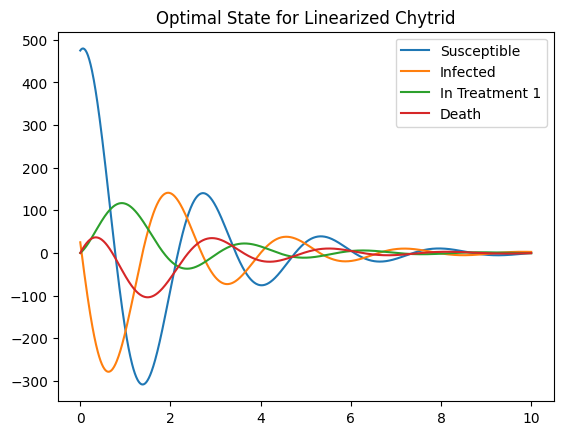

In [ ]:
# Define Q and R in our LQR model
Q = np.array([[0, 0, 0, 0],
             [0, 0, 0, 0],
             [0, 0, 0, 0],
             [0, 0, 0, 1]])
R = np.eye(2)

tf = 10 # total length of time full solution will be on (so tf = M * tn where M is however many times we linearize)

def solve_linearized(A, B, y0, tn):
    '''
    Solve for control and state given a linearized system on an interval of length tn
    x_dot = Ax + Bu
    y0 - initial conditions (or last value or previous solution to linearized system)
    tn - length of one time that system is linearized on

    returns a solution to linerized system for tn years (run solve_linearized multiple times and then
    concatenate the solutions together)

    Basically one iteration of iterated LQR (?)
    '''

    # solve continuous algebraic Riccati equation to get P
    P = la.solve_continuous_are(A, B, Q, R)

    # state equation Ax + 1/2 B R^-1 B^T lambda but lambda = -2Px by 
    def chytrid_evolve(t, y):
        return (A @ y - B @ B.T @ P @ y) # no R^-1 since thats just I

    #solve the optimal state evolution, and plot the position & velocity
    sol = solve_ivp(chytrid_evolve, [0, tf], y0, dense_output=True)
    t = np.linspace(0, tf, 1001)
    S, I, T1, D = sol.sol(t)

    # can prob just return the solution but just wanted to plot to test
    plt.title("Optimal State for Linearized Chytrid")
    plt.plot(t, S, label="Susceptible")
    plt.plot(t, I, label="Infected")
    plt.plot(t, T1, label="In Treatment 1")
    plt.plot(t, D, label="Death")
    plt.legend()


# TODO get sympy to linearize A and B from our model which is imported above with namespace m

# (A and B below are DUMMY standins to test if above code would run)
A = np.array([[0, 3, 0, 0],
             [-2, 1, 6, 6],
             [0, 0, 2, 3],
             [0, 0, 0, 1]])

B = np.array([[1, 0],
             [1, 0],
             [1, 0],
             [1, 1]])

# initial guess 
# TODO: MIGHT NEED AN INITIAL GUESS FOR CONTROL 
y0 = np.array([475, 25, 0, 0])

# TODO determine how often we want to re-linearize our system 
# TODO figure out how to iterate
solve_linearized(A, B, y0, 10)